<a href="https://colab.research.google.com/github/xioloya07-rgb/Trabajo-Grupal-Algebra/blob/main/Trabajo_Grupal_AlgebraLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

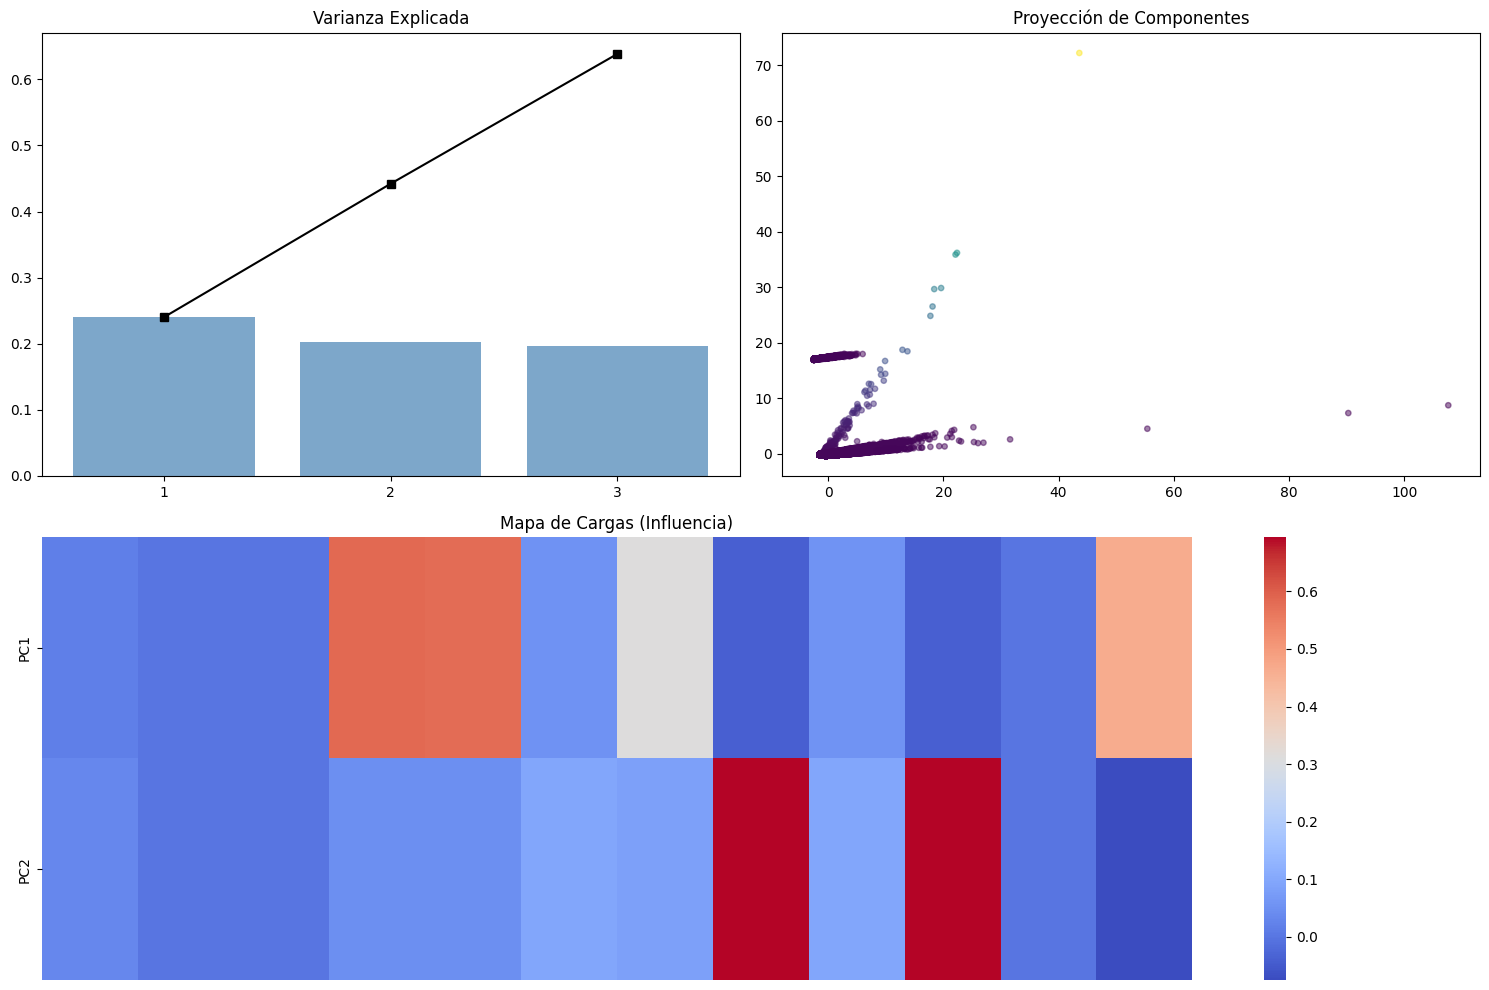

------------------------------
Resultado Manual:
⎡ 1.21214688552465  ⎤
⎢                   ⎥
⎣0.00839487438723927⎦

Resultado Sklearn: [1.21214689 0.00839487]
------------------------------


In [ ]:
import pandas as pd # Librería para manejar datos en forma de tablas (DataFrame)
import numpy as np # Librería para cálculos numéricos y manejo de arrays
import sympy as sp # Librería para matemáticas simbólicas
import matplotlib.pyplot as plt # Librería para crear gráficos
import seaborn as sns # Librería para visualizaciones estadísticas más avanzadas
from sklearn.decomposition import PCA # Importa el método de Análisis de Componentes Principales
from sklearn.preprocessing import StandardScaler # Importa herramienta para estandarizar datos
import zipfile # Permite trabajar con archivos comprimidos (.zip)
import os # Permite interactuar con el sistema de archivos

# 1. CARGA
archivo_zip = 'archive.zip' # Nombre del archivo comprimido
if os.path.exists(archivo_zip): # Verifica si el archivo existe en la ruta actual
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref: # Abre el archivo zip en modo lectura
        zip_ref.extractall('temp_data') # Extrae todos los archivos en la carpeta 'temp_data'

ruta_csv = 'temp_data/2021_Cars_Raw.csv' # Ruta del archivo CSV extraído
df = pd.read_csv(ruta_csv, low_memory=False) # Lee el CSV y lo guarda en un DataFrame

# 2. PREPROCESAMIENTO
df_num = df.select_dtypes(include=[np.number]).dropna() # Selecciona solo columnas numéricas y elimina filas con valores nulos
scaler = StandardScaler() # Crea el objeto para normalizar los datos
X_scaled = scaler.fit_transform(df_num) # Ajusta el escalador y transforma los datos

# 3. ACP
pca = PCA(n_components=3) # Crea el modelo PCA con 3 componentes principales
coords = pca.fit_transform(X_scaled) # Ajusta el modelo y transforma los datos a un nuevo espacio
var_ind = pca.explained_variance_ratio_ # Obtiene la varianza explicada por cada componente
var_cum = np.cumsum(var_ind) # Calcula la varianza acumulada
loadings = pca.components_.T[:, :2] # Obtiene las cargas (influencia de variables) para las primeras 2 componentes

# 4. TRES GRÁFICOS (SIN TEXTO INTERNO)
fig = plt.figure(figsize=(15, 10)) # Crea una figura para colocar los gráficos

# Gráfico 1: Varianza
ax1 = fig.add_subplot(2, 2, 1) # Crea un subgráfico en la posición 1 de una cuadrícula 2x2
ax1.bar(range(1, 4), var_ind, color='steelblue', alpha=0.7) # Grafica barras con la varianza individual
ax1.plot(range(1, 4), var_cum, marker='s', color='black') # Grafica la varianza acumulada como línea
ax1.set_title('Varianza Explicada') # Título del gráfico
ax1.set_xticks([1, 2, 3]) # Define las etiquetas del eje X

# Gráfico 2: Dispersión
ax2 = fig.add_subplot(2, 2, 2) # Crea el segundo subgráfico
ax2.scatter(coords[:, 0], coords[:, 1], c=coords[:, 2], cmap='viridis', s=15, alpha=0.5) # Gráfico de dispersión usando PC1 y PC2, coloreado por PC3
ax2.set_title('Proyección de Componentes') # Título del gráfico

# Gráfico 3: Cargas (Mapa de Calor sin etiquetas de variables)
ax3 = fig.add_subplot(2, 1, 2) # Crea un subgráfico que ocupa toda la parte inferior
sns.heatmap(loadings.T, cmap='coolwarm', ax=ax3, cbar=True, xticklabels=False) # Mapa de calor de las cargas sin nombres de variables
ax3.set_title('Mapa de Cargas (Influencia)') # Título del mapa de calor
ax3.set_yticklabels(['PC1', 'PC2']) # Etiquetas del eje Y

plt.tight_layout() # Ajusta automáticamente los espacios entre gráficos
plt.show() # Muestra los gráficos

# 5. VERIFICACIÓN SYMPY
print("-" * 30) # Imprime una línea separadora
x_v = sp.Matrix(X_scaled[0]) # Convierte la primera fila en vector columna
B_v = sp.Matrix(pca.components_[:2, :]) # Convierte las componentes principales en matriz
resultado = B_v * x_v # Multiplica para obtener la proyección manual
print("Resultado Manual:") # Texto descriptivo
sp.pprint(resultado) # Imprime el resultado en formato matemático
print(f"\nResultado Sklearn: {coords[0, :2]}") # Muestra el resultado obtenido con sklearn
print("-" * 30) # Imprime otra línea separadora